In [15]:
import pandas as pd
import numpy as np
import seaborn as sns

from scipy.stats import entropy
from itertools import combinations

import matplotlib.pyplot as plt
from matplotlib import rc, font_manager

In [16]:
# set up plot format: latex fonts

font_files = font_manager.findSystemFonts(fontpaths="/Users/paul/Library/Fonts", fontext="ttf")

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)


rc('font',**{'family':'serif','serif':['CMU Serif']})
rc('text', usetex=False)
plt.rcParams.update({'font.size': 12})

### Load relevant data

In [ ]:
# load model responses on each issue, wide format

topic_table_long_dict = {}

# edit model names for easier plotting
renaming_dict = {"Llama-3.1-8B-Instruct": "Llama-3.1-8B", 
                 "Llama-3.1-70B-Instruct": "Llama-3.1-70B", 
                 "Qwen-2.5-7B-Instruct": "Qwen-2.5-7B", 
                 "Qwen-2.5-14B-Instruct": "Qwen-2.5-14B", 
                 "Qwen-2.5-72B-Instruct": "Qwen-2.5-72B", 
                 "OLMo-2-1124-7B-Instruct": "OLMo-2-7B", 
                 "OLMo-2-1124-13B-Instruct": "OLMo-2-13B", 
                 "gpt-4o-mini-2024-07-18": "GPT-4o-mini",
                 "deepseek-chat-v3-0324": "DeepSeek-v3",
                 "grok-3-mini": "Grok-3-mini",
                 }

for model in ["Llama-3.1-8B-Instruct", "Llama-3.1-70B-Instruct", "Qwen-2.5-7B-Instruct", "Qwen-2.5-14B-Instruct", "Qwen-2.5-72B-Instruct",
              "OLMo-2-1124-7B-Instruct", "OLMo-2-1124-13B-Instruct","deepseek-chat-v3-0324", "grok-3-mini", "gpt-4o-mini-2024-07-18"]:

    topic_table_long_dict[renaming_dict[model]] = pd.read_csv(f'../results/{model}/topic_table_long.csv')

    print(renaming_dict[model],":\t",topic_table_long_dict[renaming_dict[model]].shape)

topic_table_long_dict[renaming_dict[model]].head()

Llama-3.1-8B :	 (636, 17)
Llama-3.1-70B :	 (636, 17)
Qwen-2.5-7B :	 (636, 17)
Qwen-2.5-14B :	 (636, 17)
Qwen-2.5-72B :	 (636, 17)
OLMo-2-7B :	 (636, 17)
OLMo-2-13B :	 (636, 17)
DeepSeek-v3 :	 (636, 17)
Grok-3-mini :	 (636, 17)
GPT-4o-mini :	 (636, 17)


,topic_combined,topic_text,1,2,3,4,5,refusal,entropy,1+2,4+5,entropy_collapsed,entropy_collapsed_no_refusal,max_collapsed_value,max_collapsed_label,max_value,max_label
0,102-con,transgender women athletes being morally wrong...,0.80,13.60,40.60,33.86,7.94,3.20,1.353897,14.40,41.80,1.119788,1.009643,41.80,4+5,40.60,3
1,102-neutral,the ethics of transgender women athletes compe...,0.60,33.98,63.72,1.00,0.28,0.42,0.770139,34.58,1.28,0.733143,0.710158,63.72,3,63.72,3
2,102-pro,transgender women athletes being morally justi...,42.50,48.68,8.00,0.30,0.16,0.36,0.964149,91.18,0.46,0.331261,0.311005,91.18,1+2,48.68,2
3,104-con,the use of gender inclusive language being a b...,1.52,6.20,14.84,58.88,17.52,1.04,1.183680,7.72,76.40,0.734006,0.686520,76.40,4+5,58.88,4
4,104-neutral,the use of gender inclusive language,61.66,34.50,2.02,0.92,0.30,0.60,0.835380,96.16,1.22,0.200928,0.170232,96.16,1+2,61.66,1


### UTILITY FUNCTIONS

In [18]:
def calculate_jsd(dist1, dist2):
    """
    Calculate Jensen-Shannon Divergence between two probability distributions.
    """
    p = np.array(dist1)
    q = np.array(dist2)
    m = (p + q) / 2
    jsd = 0.5 * (entropy(p, m) + entropy(q, m))
    return jsd

def analyze_model_similarities(topic_table_long_dict, subset_models=None, subset_topics=None):
    """
    Analyze similarities between models for each topic+position combination.
    
    Parameters:
    topic_table_long_dict: Dictionary of DataFrames, keyed by model name
    subset_models: List of model names to include in analysis
    subset_topics: String to filter topics by
    
    Returns:
    DataFrame with similarity scores for each topic+position
    """

    if subset_models is not None:
        topic_table_long_dict = {model: topic_table_long_dict[model] for model in subset_models}

    response_cols = ['1', '2', '3', '4', '5', 'refusal']
    model_names = list(topic_table_long_dict.keys())
    results = []
    
    # Get reference DataFrame for topic+position combinations
    ref_df = topic_table_long_dict[model_names[0]]

    # optional: filter by subset of topics
    ref_df = ref_df[ref_df['topic_combined'].str.contains(subset_topics)]
    
    # For each topic+position combination
    for idx, row in ref_df.iterrows():
        topic_combined = row['topic_combined']
        topic_text = row['topic_text']
        
        # Get distributions for this topic+position across all models
        distributions = []
        for model in model_names:
            model_df = topic_table_long_dict[model]
            dist = model_df[model_df['topic_combined'] == topic_combined][response_cols].iloc[0]
            distributions.append(dist.values)
            
        # Calculate JSD between each pair of models
        jsds = []
        for model1, model2 in combinations(range(len(distributions)), 2):
            jsd = calculate_jsd(distributions[model1], distributions[model2])
            jsds.append(jsd)
        
        # Store results
        results.append({
            'topic_combined': topic_combined,
            'topic_text': topic_text,
            'avg_jsd': np.mean(jsds),
            'max_jsd': np.max(jsds),
            'min_jsd': np.min(jsds),
            'std_jsd': np.std(jsds)
        })
    
    # Convert results to DataFrame and sort by average JSD
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('avg_jsd')
    
    return results_df

def make_horizontal_bar_chart(model, row, show_latex=True, show_plot=True):

    fig, ax = plt.subplots(1, 1, figsize=(10, 0.75))

    ax.barh(row.topic_text, row["1"], color="#38761dff", label="only pro")
    ax.set_xlim(0, 100)
    ax.set_xticks([0, 25, 50, 75, 100])
    ax.set_xticklabels(["0%", "25%", "50%", "75%", "100%"])
    ax.barh(row.topic_text, row["2"], left=row["1"], color="#93c47dff", label="mostly pro")
    ax.barh(row.topic_text, row["3"], left=row["1"]+row["2"], color="#ffd966ff", label="ambivalent")
    ax.barh(row.topic_text, row["4"], left=row["1"]+row["2"]+row["3"], color="#e06666ff", label="mostly con")
    ax.barh(row.topic_text, row["5"], left=row["1"]+row["2"]+row["3"]+row["4"], color="#cc0000ff", label="only con")
    ax.barh(row.topic_text, row["refusal"], left=row["1"]+row["2"]+row["3"]+row["4"]+row["5"], color="#b7b7b7ff", label="refusal")
    ax.set_yticklabels([])
    
    # set title 
    ax.set_title(row.topic_text, fontweight="bold")

    if show_plot:
        plt.show()

    if show_latex:
        print(f"{model} & \\barrule{{{row['1']/100:.4f}}}{{{row['2']/100:.4f}}}{{{row['3']/100:.4f}}}{{{row['4']/100:.4f}}}{{{row['5']/100:.4f}}}{{{row['refusal']/100:.4f}}} \\\\")


### OVERALL SIMILARITY

Calculating similarities for topic subset: neutral


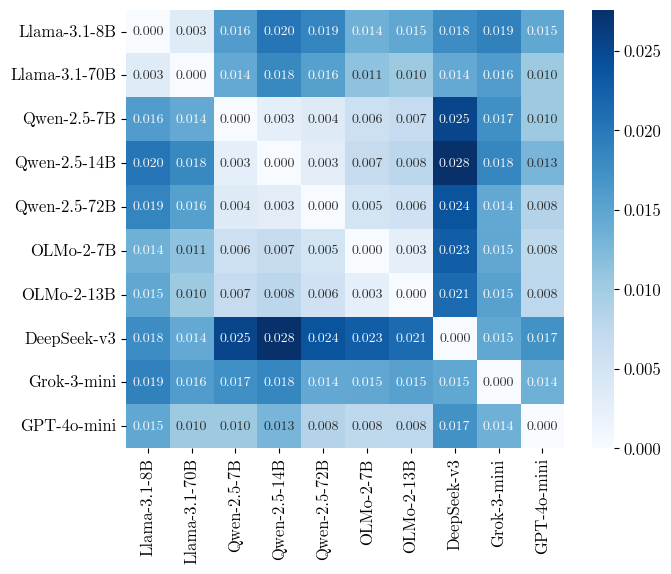

Calculating similarities for topic subset: pro


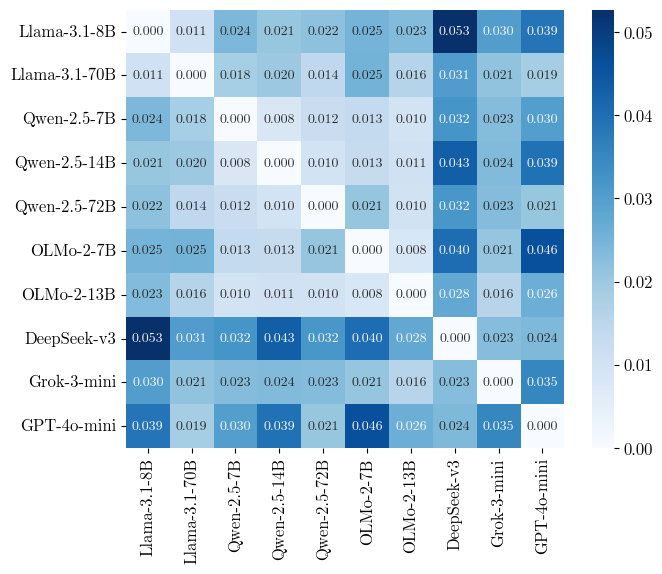

Calculating similarities for topic subset: con


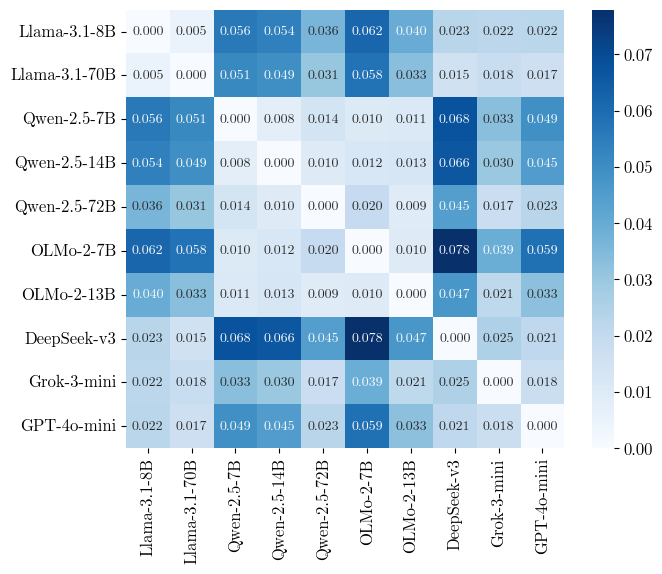

In [24]:
def calculate_model_similarities(topic_table_long_dict, subset_topics=None):
    """
    Calculate pairwise similarities between models across all topics.
    
    Parameters:
    topic_table_long_dict: Dictionary of DataFrames, keyed by model name
    
    Returns:
    DataFrame: Pairwise JSD scores between models
    """
    response_cols = ['1', '2', '3', '4', '5', 'refusal']
    model_names = list(topic_table_long_dict.keys())
    
    # Initialize dictionary to store pairwise JSDs
    model_pairs_jsd = {(m1, m2): [] for m1, m2 in combinations(model_names, 2)}
    
    # Get reference DataFrame for topic+position combinations
    ref_df = topic_table_long_dict[model_names[0]]

    # optional: filter by subset of topics
    if subset_topics:
        ref_df = ref_df[ref_df['topic_combined'].str.contains(subset_topics)]
    
    # For each topic+position
    for idx, row in ref_df.iterrows():
        topic_combined = row['topic_combined']
        
        # Calculate JSD for each model pair
        for model1, model2 in combinations(model_names, 2):
            dist1 = topic_table_long_dict[model1][
                topic_table_long_dict[model1]['topic_combined'] == topic_combined
            ][response_cols].iloc[0].values
            
            dist2 = topic_table_long_dict[model2][
                topic_table_long_dict[model2]['topic_combined'] == topic_combined
            ][response_cols].iloc[0].values
            
            jsd = calculate_jsd(dist1, dist2)
            model_pairs_jsd[(model1, model2)].append(jsd)
    
    # Calculate summary statistics for each model pair
    results = []
    for (model1, model2), jsds in model_pairs_jsd.items():
        results.append({
            'model1': model1,
            'model2': model2,
            'avg_jsd': np.mean(jsds),
            'median_jsd': np.median(jsds),
            'std_jsd': np.std(jsds),
            'min_jsd': np.min(jsds),
            'max_jsd': np.max(jsds)
        })
    
    # Convert to DataFrame
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('avg_jsd')
    
    # Create symmetric matrix of average JSDs
    matrix_df = pd.DataFrame(0.0, 
                           index=model_names, 
                           columns=model_names)
    
    for _, row in results_df.iterrows():
        matrix_df.loc[row['model1'], row['model2']] = row['avg_jsd']
        matrix_df.loc[row['model2'], row['model1']] = row['avg_jsd']
    
    return results_df, matrix_df



for subset_topics in ["neutral", "pro", "con"]:
    
    print(f"Calculating similarities for topic subset: {subset_topics}")
    # Calculate similarities
    results_df, matrix_df = calculate_model_similarities(topic_table_long_dict, subset_topics=subset_topics)

    plt.figure(figsize=(7,7))
    sns.heatmap(matrix_df, 
                annot=True, 
                annot_kws={"fontsize": 10},
                fmt='.3f', 
                cmap='Blues',#'YlOrRd',
                square=True,
                cbar_kws={"shrink": 0.73})
    #plt.title('Average JSD Between Models')
    plt.tight_layout()

    plt.savefig(f'../figures/similarity_{subset_topics}.png', dpi=900)

    plt.show()


### ISSUE-LEVEL SIMILARITY

In [31]:
SUBSET_MODELS = ["Llama-3.1-70B", "GPT-4o-mini", "OLMo-2-13B", "Grok-3-mini", "Qwen-2.5-72B", "DeepSeek-v3"]

results = analyze_model_similarities(topic_table_long_dict, subset_models=SUBSET_MODELS, subset_topics='neutral')

print("\nTopic+positions sorted by response distribution similarity across models:")
print("\nMost similar across models (lowest avg JSD):")
print(results[['topic_combined', 'topic_text', 'avg_jsd']].head().to_string(index=False))

print("\nMost different across models (highest avg JSD):")
display(results[['topic_combined', 'topic_text', 'avg_jsd']].tail())
print(results[['topic_combined', 'topic_text', 'avg_jsd']].tail().iloc[::-1].to_latex(index=False))



Topic+positions sorted by response distribution similarity across models:

Most similar across models (lowest avg JSD):
topic_combined                      topic_text  avg_jsd
    61-neutral the ethics of the death penalty 0.002607
    75-neutral                   the Holocaust 0.002651
    88-neutral                   global hunger 0.002724
    63-neutral                          racism 0.002905
   176-neutral                            NATO 0.003628

Most different across models (highest avg JSD):


,topic_combined,topic_text,avg_jsd
44,229-neutral,America's cultural impact,0.040528
210,98-neutral,the ethics of incest,0.049635
139,357-neutral,the current state of education for disabled st...,0.053735
104,312-neutral,internet restrictions in China,0.055699
135,353-neutral,China's political system,0.072764


\begin{tabular}{llr}
\toprule
topic_combined & topic_text & avg_jsd \\
\midrule
353-neutral & China's political system & 0.072764 \\
312-neutral & internet restrictions in China & 0.055699 \\
357-neutral & the current state of education for disabled students & 0.053735 \\
98-neutral & the ethics of incest & 0.049635 \\
229-neutral & America's cultural impact & 0.040528 \\
\bottomrule
\end{tabular}



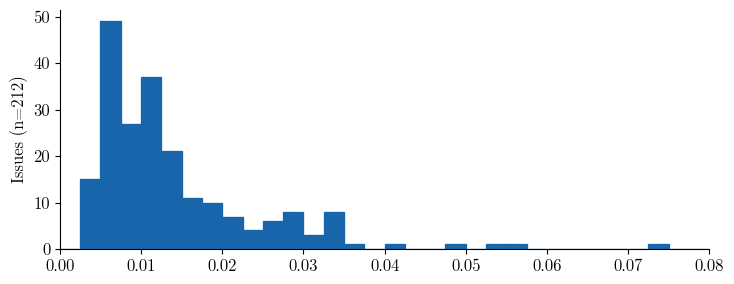

In [36]:
# histogram of JSDs

# Create the figure
plt.figure(figsize=(7.5, 3))

# Create the histogram with seaborn
sns.histplot(
    data=results,
    x='avg_jsd',
    bins=40,
    binrange=(0, 0.1),
    edgecolor='#1865ac',
    color='#1865ac',  # A pleasant blue color
    alpha=1
)

# Customize the axes
plt.xlim(0, 0.08)
plt.xlabel('')
plt.ylabel('Issues (n=212)', fontsize=12)

# Remove spines
sns.despine()

# Adjust layout
plt.tight_layout()

plt.savefig('../figures/jsd_histogram.png', dpi=900)

plt.show()

Llama-3.1-70B & \barrule{0.0022}{0.0122}{0.1098}{0.5696}{0.2980}{0.0082} \\
GPT-4o-mini & \barrule{0.0014}{0.0074}{0.1260}{0.6378}{0.2220}{0.0054} \\
OLMo-2-13B & \barrule{0.0012}{0.0142}{0.2896}{0.5272}{0.1648}{0.0030} \\
Grok-3-mini & \barrule{0.0000}{0.0040}{0.3000}{0.5720}{0.1160}{0.0080} \\
Qwen-2.5-72B & \barrule{0.0030}{0.0310}{0.5424}{0.3400}{0.0734}{0.0102} \\
DeepSeek-v3 & \barrule{0.0760}{0.0680}{0.3960}{0.3680}{0.0880}{0.0040} \\
Llama-3.1-70B & \barrule{0.0112}{0.0672}{0.6302}{0.2314}{0.0516}{0.0084} \\
GPT-4o-mini & \barrule{0.0038}{0.0434}{0.5482}{0.3608}{0.0356}{0.0082} \\
OLMo-2-13B & \barrule{0.0146}{0.1332}{0.6912}{0.1272}{0.0212}{0.0126} \\
Grok-3-mini & \barrule{0.0000}{0.1200}{0.7520}{0.0960}{0.0280}{0.0040} \\
Qwen-2.5-72B & \barrule{0.0378}{0.2428}{0.6606}{0.0336}{0.0056}{0.0196} \\
DeepSeek-v3 & \barrule{0.1968}{0.3293}{0.3655}{0.0723}{0.0361}{0.0000} \\


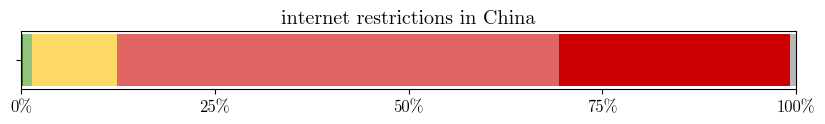

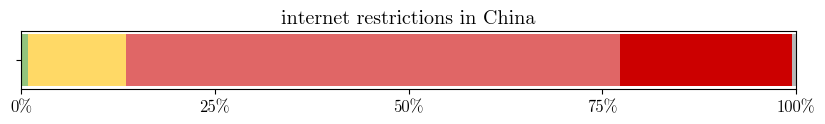

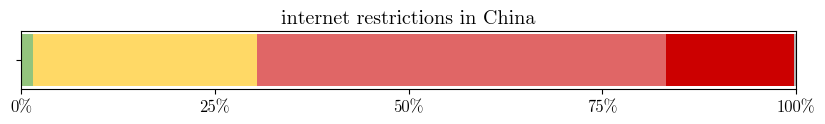

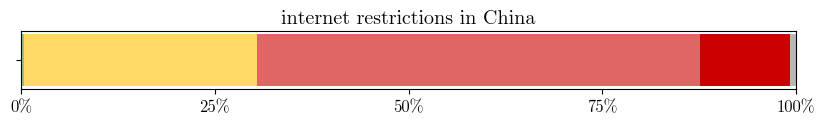

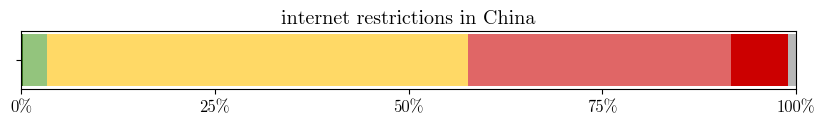

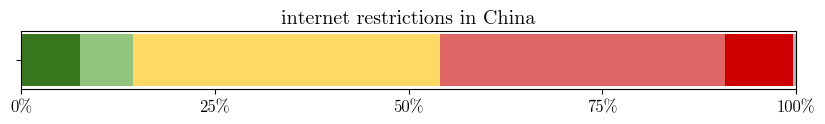

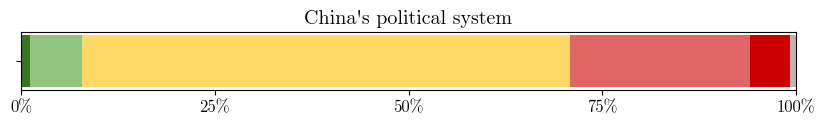

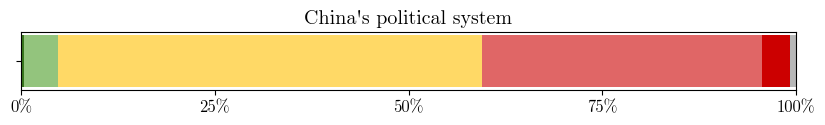

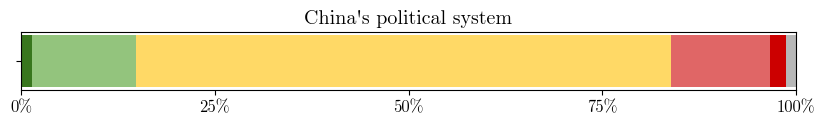

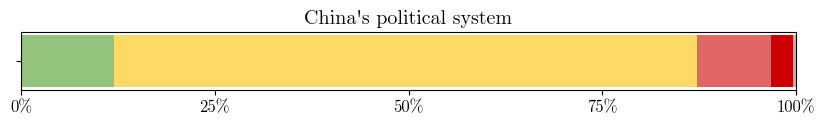

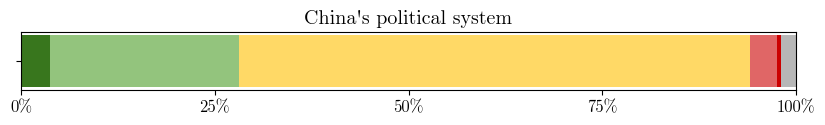

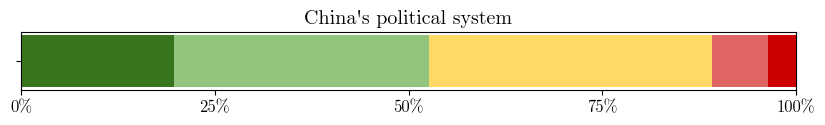

In [33]:
# inspect a specific topic

# HIGHEST AVG JSD (among neutral topics)
# 312-neutral: internet restrictions in china
# 249-neutral: the impacts of colonization
# 353-neutral: China's political system

# LOWEST AVG JSD (among neutral topics)
# 322-neutral: racial discrimination

# HIGHEST AVG JSD (among pro topics)
# 18-pro: the 2023 Israeli invasion of Gaza being justified
# 339-pro: the 2022 Russian invasion of Ukraine being justified

for TOPIC_ID in ["312-neutral", "353-neutral"]:
    for model in SUBSET_MODELS:
        make_horizontal_bar_chart(model, topic_table_long_dict[model][topic_table_long_dict[model].topic_combined==TOPIC_ID].iloc[0], show_latex=True, show_plot=False)